In [128]:
import torch
import matplotlib.pyplot as plt

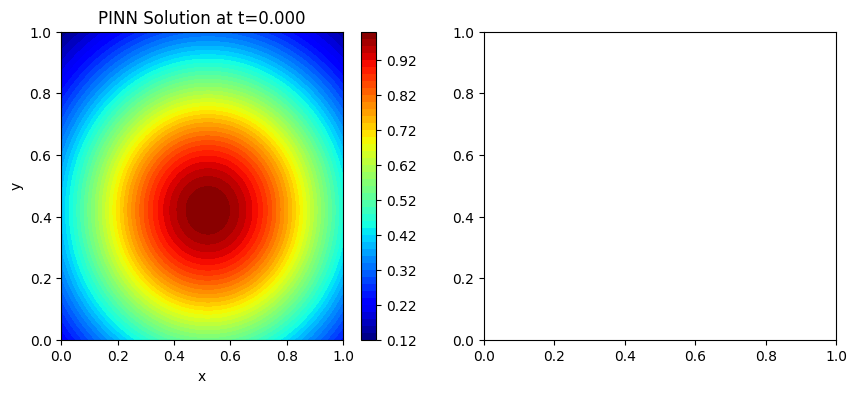

In [129]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

def u_analytic(X):
    t = X[:,-1]
    x = X[:,:-1]
    #return (torch.exp(-t) * torch.cos(x[:,0]+0.9*t) * torch.cos(x[:,1]+1.3*t)).unsqueeze(dim=1)
    #r2 = (0.9*x[:,0]-0.4+t)**2 + (x[:,1]-0.6+t)**2
    #return ( torch.exp(-r2) ).unsqueeze(dim=1)
    r2 = (x[:,0]-0.3*t-0.52)**2 + (x[:,1]+0.2*t-0.42)**2
    return (torch.exp(-3.4*r2)*torch.exp(-0.2*t)*torch.cos(0.8*torch.pi*t) ).unsqueeze(dim=1)
    #r2 = (x[:,0]-0.4+0.5*torch.sin(2*t))**2 + (x[:,1]-0.3+0.1*t)**2
    #return (torch.cos(1.45*torch.pi*t) * torch.exp(-2*r2)*torch.exp(-t) ).unsqueeze(dim=1)


N = 100
t_val = 0.0

# DO ONCE
x = torch.linspace(0, 1, N, device=device)
y = torch.linspace(0, 1, N, device=device)
X_grid, Y_grid = torch.meshgrid(x, y, indexing='ij')
x_flat = X_grid.reshape(-1, 1)
y_flat = Y_grid.reshape(-1, 1)

t_flat = torch.ones_like(x_flat) * t_val
X = torch.cat([x_flat, y_flat, t_flat], dim=1)


# Analytical solution
u_true = u_analytic(X)
U_true = u_true.reshape(N, N)


fig, axes = plt.subplots(1, 2, figsize=(10, 4))

# Predicted solution
im1 = axes[0].contourf(X_grid, Y_grid, U_true, levels=50, cmap='jet')
axes[0].set_title(f'PINN Solution at t={t_val:.3f}')
axes[0].set_xlabel('x')
axes[0].set_ylabel('y')
plt.colorbar(im1, ax=axes[0])

In [130]:
global_max

tensor(0.9999)

0.0
0.014925373134328358
0.029850746268656716
0.04477611940298507
0.05970149253731343
0.07462686567164178
0.08955223880597014
0.1044776119402985
0.11940298507462686
0.13432835820895522
0.14925373134328357
0.16417910447761194
0.1791044776119403
0.19402985074626866
0.208955223880597
0.22388059701492538
0.23880597014925373
0.2537313432835821
0.26865671641791045
0.2835820895522388
0.29850746268656714
0.31343283582089554
0.3283582089552239
0.34328358208955223
0.3582089552238806
0.373134328358209
0.3880597014925373
0.40298507462686567
0.417910447761194
0.43283582089552236
0.44776119402985076
0.4626865671641791
0.47761194029850745
0.4925373134328358
0.5074626865671642
0.5223880597014925
0.5373134328358209
0.5522388059701493
0.5671641791044776
0.582089552238806
0.5970149253731343
0.6119402985074627
0.6268656716417911
0.6417910447761194
0.6567164179104478
0.6716417910447762
0.6865671641791045
0.7014925373134329
0.7164179104477612
0.7313432835820896
0.746268656716418
0.7611940298507462
0.7761194

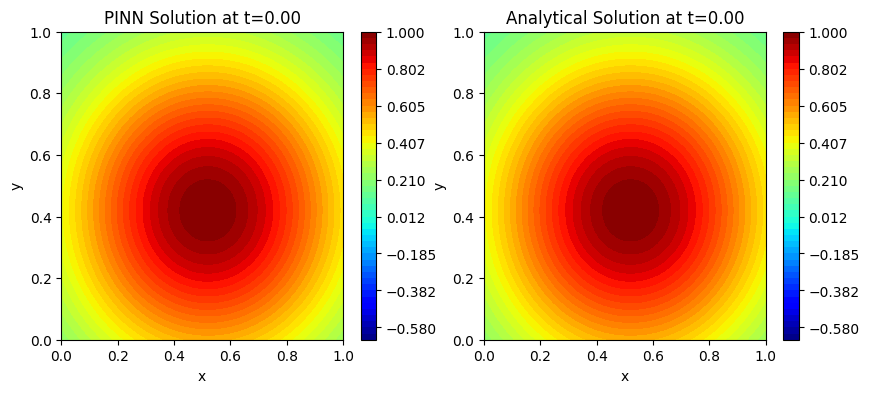

In [131]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation

# Assume these are defined: N, X (NxN+1 array for [x,y,t]), X_grid, Y_grid, u_analytic(X)
# Example setup if missing (adapt to your exact vars):
# N = ...  # e.g., 100
# X = np.random.uniform(0, 2*np.pi, (N*N+1, 3))  # [x,y,t]
# ... etc.

def update_grid(t_val):
    X[:,-1] = t_val  # Update t column
    U_true = u_analytic(X)
    return U_true

# Compute global min/max for fixed color range
num_frames = 67
global_min, global_max = np.inf, -np.inf
for frame_indx in range(num_frames):
    t_val = frame_indx / num_frames
    print(t_val)
    U_true = update_grid(t_val)
    global_min = min(global_min, U_true.min())
    global_max = max(global_max, U_true.max())

levels = np.linspace(global_min, global_max, 51)  # 50 intervals [web:7][web:12]

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

# Initial plots with FIXED levels for static colorbars
t_val = 0.0
U_true = update_grid(t_val).reshape(N, N)

im1 = axes[0].contourf(X_grid, Y_grid, U_true, levels=levels, cmap='jet')
axes[0].set_title(f'PINN Solution at t={t_val:.2f}')
cbar1 = plt.colorbar(im1, ax=axes[0])
axes[0].set_xlabel('x')
axes[0].set_ylabel('y')

im2 = axes[1].contourf(X_grid, Y_grid, U_true, levels=levels, cmap='jet')
axes[1].set_title(f'Analytical Solution at t={t_val:.2f}')
cbar2 = plt.colorbar(im2, ax=axes[1])
axes[1].set_xlabel('x')
axes[1].set_ylabel('y')

# Animation update: clear prior contours, redraw with same levels
def update(frame_indx):
    t_val = frame_indx / num_frames
    U_true_full = update_grid(t_val)
    U_true = U_true_full.reshape(N, N)

    # Clear previous contour collections [web:9][web:20]
    for ax in axes:
        while ax.collections:
            ax.collections[0].remove()
    
    # Redraw with FIXED levels
    axes[0].contourf(X_grid, Y_grid, U_true, levels=levels, cmap='jet')
    axes[0].set_title(f'PINN Solution at t={t_val:.2f}')
    
    axes[1].contourf(X_grid, Y_grid, U_true, levels=levels, cmap='jet')
    axes[1].set_title(f'Analytical Solution at t={t_val:.2f}')
    
    return []

FPS = 10
print("Saving animation...")
ani = FuncAnimation(fig, update, frames=range(num_frames), interval=int(1000/FPS), blit=False, repeat=False)
ani.save("brainstorm_pde.gif", writer="ffmpeg", fps=FPS, dpi=100)
print("Animation saved.")


---

In [206]:
import sympy as sp
import torch
import sympytorch

t, x, y = sp.symbols('t x y')  # Names are now 't', 'x', 'y' as strings
alpha_sym, vx_sym, vy_sym, c_sym = sp.symbols(r'\alpha v_x v_y c')  # Or use 'alpha vx vy c'
u_expr = sp.sin(t) * sp.exp(-x**2 - y**2)

dt_u = sp.diff(u_expr, t)
lap_u = sp.diff(u_expr, x, 2) + sp.diff(u_expr, y, 2)
grad_u_x = sp.diff(u_expr, x)
grad_u_y = sp.diff(u_expr, y)
adv_u = vx_sym * grad_u_x + vy_sym * grad_u_y
lhs = dt_u - alpha_sym * lap_u + adv_u + c_sym * u_expr

mod = sympytorch.SymPyModule(expressions=[lhs])

# Inputs: keys MUST be symbol .name strings, values tensors (batched ok)
inputs = {
    t.name: torch.tensor(1.0),      # 't': ...
    x.name: torch.tensor(0.5),
    y.name: torch.tensor(0.3),
    alpha_sym.name: torch.tensor(0.1, requires_grad=True),
    vx_sym.name: torch.tensor(1.0),
    vy_sym.name: torch.tensor(0.5),
    c_sym.name: torch.tensor(0.2)
}
output = mod(**inputs)
print(output)  # tensor([...], grad_fn=<...>)

# Loss example
f_val = torch.tensor(0.0)
loss = (output - f_val)**2
loss.backward()
print(alpha_sym.name, inputs[alpha_sym.name].grad)  # Nonzero if depends on alpha


tensor([-0.1161], grad_fn=<StackBackward0>)
\alpha tensor(-0.3673)


In [207]:
lhs

-\alpha*(2*(2*x**2 - 1)*exp(-x**2 - y**2)*sin(t) + 2*(2*y**2 - 1)*exp(-x**2 - y**2)*sin(t)) + c*exp(-x**2 - y**2)*sin(t) - 2*v_x*x*exp(-x**2 - y**2)*sin(t) - 2*v_y*y*exp(-x**2 - y**2)*sin(t) + exp(-x**2 - y**2)*cos(t)

In [142]:
import sympy as sp
import numpy as np

def make_nd_function(d, func_type='gaussian'):
    # d vars: x0, x1, ..., x_{d-1}
    xs = sp.symbols(' '.join(f'x{i}' for i in range(d)))
    
    if func_type == 'gaussian':
        r2 = sum(xi**2 for xi in xs)
        u = sp.exp(-r2)
    elif func_type == 'plane_wave':
        kdotx = sum(sp.symbols(f'k{i}') * xi for i, xi in enumerate(xs))
        u = sp.sin(kdotx)
    # Add more: polynomial, etc.
    
    # Derivatives for PDE
    dt_u = sp.diff(u, 't') if 't' in u.free_symbols else 0  # Assume t separate
    grad_u = [sp.diff(u, xi) for xi in xs]
    lap_u = sum(sp.diff(u, xi, 2) for xi in xs)
    
    return u, xs, grad_u, lap_u  # Plus v · ∇u = sum(v_i * grad_i)

d = 5  # Arbitrary: 2,3,...
u, xs, grad_u, lap_u = make_nd_function(d)
print(f'u({[x.name for x in xs]}) = {u}')  # e.g., exp(-x0**2 -x1**2 -x2**2)


u(['x0', 'x1', 'x2', 'x3', 'x4']) = exp(-x0**2 - x1**2 - x2**2 - x3**2 - x4**2)


In [145]:
import torch
import sympytorch

# After SymPy: assume lhs expr (PDE left), with xs + params
#lhs = ...  # e.g., dt_u - alpha*lap_u + adv_u + c*u  (build dynamically)
mod = sympytorch.SymPyModule(expressions=[lhs])

def eval_nd_pde(mod, d, shape, h=0.1, alpha=0.1, c=0.2, vs=None):
    # Arbitrary spatial grid: shape = [Nx0, Nx1, ..., Nxd-1]
    grids = [torch.linspace(-1, 1, s) for s in shape]
    coords = torch.meshgrid(*grids, indexing='ij')  # d tensors, each shape
    t_grid = torch.linspace(0, 1, 10)  # Time separate
    inputs = {t.name: t_grid[:, None]*torch.ones(np.prod(shape), 1) if 't' in locals() else torch.tensor(0.0)}
    
    for i in range(d):
        inputs[xs[i].name] = coords[i].flatten()
    
    inputs.update({  # Params
        'alpha': torch.full((np.prod(shape)*len(t_grid),), alpha, requires_grad=True),
        'c': torch.full_like(inputs['alpha'], c),
        'v0': torch.tensor(1.0), 'v1': torch.tensor(0.5),  # Broadcast; extend for d
    })
    for i in range(1, d):  # v1 to v_{d-1}
        inputs[f'v{i}'] = torch.tensor(0.1)
    
    output = mod(**inputs).reshape(len(t_grid), *shape)
    return output  # PDE residual tensor

# Usage
d = 4  # Arbitrary!
shape = [32, 32, 16, 16]  # Nx0 x Nx1 x ...
residual = eval_nd_pde(mod, d, shape)
loss = torch.mean(residual**2)
loss.backward()


KeyError: 'alpha'

In [146]:
import sympy as sp

t, x, y = sp.symbols('t x_0 y')
alpha, vx, vy, c = sp.symbols('alpha v_x v_y c')
u = sp.sin(t) * sp.exp(-x**2 - y**2)

dt_u = sp.diff(u, t)
lap_u = sp.diff(u, x, 2) + sp.diff(u, y, 2)
grad_u = [sp.diff(u, x), sp.diff(u, y)]
adv_u = vx * grad_u[0] + vy * grad_u[1]
lhs = dt_u - alpha * lap_u + adv_u + c * u

lhs

-alpha*(2*(2*x_0**2 - 1)*exp(-x_0**2 - y**2)*sin(t) + 2*(2*y**2 - 1)*exp(-x_0**2 - y**2)*sin(t)) + c*exp(-x_0**2 - y**2)*sin(t) - 2*v_x*x_0*exp(-x_0**2 - y**2)*sin(t) - 2*v_y*y*exp(-x_0**2 - y**2)*sin(t) + exp(-x_0**2 - y**2)*cos(t)

In [147]:
# d vars: x0, x1, ..., x_{d-1}
xs = sp.symbols(' '.join(f'x{i}' for i in range(d)))

r2 = sum(xi**2 for xi in xs)
u = sp.exp(-r2)
kdotx = sum(sp.symbols(f'k{i}') * xi for i, xi in enumerate(xs))
u = sp.sin(kdotx)
# Add more: polynomial, etc.

# Derivatives for PDE
dt_u = sp.diff(u, 't') if 't' in u.free_symbols else 0  # Assume t separate
grad_u = [sp.diff(u, xi) for xi in xs]
lap_u = sum(sp.diff(u, xi, 2) for xi in xs)
    

d = 5  # Arbitrary: 2,3,...
u, xs, grad_u, lap_u = make_nd_function(d)
print(f'u({[x.name for x in xs]}) = {u}')  # e.g., exp(-x0**2 -x1**2 -x2**2)

u(['x0', 'x1', 'x2', 'x3', 'x4']) = exp(-x0**2 - x1**2 - x2**2 - x3**2 - x4**2)


In [18]:
import torch
d = 2
a = torch.rand((10,d))
b = torch.ones((10,1))
a + b

tensor([[1.5899, 1.4449],
        [1.6347, 1.5892],
        [1.8817, 1.8668],
        [1.6295, 1.9510],
        [1.1874, 1.0740],
        [1.8335, 1.6098],
        [1.4275, 1.4953],
        [1.5300, 1.1373],
        [1.1212, 1.0466],
        [1.6338, 1.6661]])

---

##

PDE:
$$
\partial_t u - \delta \Delta u + \vec{v} \cdot \nabla u + w\, u = f
$$
1) supp you like to get a solution:
$$
u(x,t) = e^{-\alpha\sum_{i=1}^d(a_i x_i - b_i + c_i t)^2}
$$
how should the $f$ look like?

You get:
$$
f = \partial_t u - \delta \Delta u + \vec{v} \cdot \nabla u + w\, u \\
= \Bigg(
    -2\alpha\Big(
        \sum (v_i a_i + c_i)(a_ix_i-b_i+c_it) +
        \delta \sum a_i^2\big(2\alpha(a_ix_i-b_i+c_it)^2-1\big)
    \Big)
    +w
\Bigg)\,u(x,t)
$$

2) supp that you would like $\tilde u$ to be the solution
$$
\tilde u(x,t) =  u(x,t)\,h(t)\,, \quad h(t) = e^{-\beta t}\cos{\gamma t}
$$
how should the $\tilde f$ look like?
$$
\tilde f = \partial_t \tilde u - \delta \Delta \tilde u + \vec{v} \cdot \nabla \tilde u + w\, \tilde u \\
= \partial_t u \,h + u\,\partial_t h + (- \delta \Delta u + \vec{v} \cdot \nabla u + w\, u)\, h \\
= u\,\partial_t h + (\partial_t u - \delta \Delta u + \vec{v} \cdot \nabla u + w\, u)\, h \\
= u\,\partial_t h + f\,h \\
= \Bigg[\Bigg(
    -2\alpha\Big(
        \sum (v_i a_i + c_i)(a_ix_i-b_i+c_it) +
        \delta \sum a_i^2\big(2\alpha(a_ix_i-b_i+c_it)^2-1\big)
    \Big)
    +w
\Bigg)\,h(t) + \partial_t h(t) \Bigg] u(x,t) \\
= \Bigg[\Bigg(...\Bigg)\,h(t) + \partial_t h(t) \Bigg] u(x,t) \\
= \Bigg[\Bigg(...\Bigg)\,\cos{\gamma t} - \beta \cos{\gamma t} - \gamma \sin{\gamma t} \Bigg]
e^{-\beta t} u(x,t) \\
= \Bigg[\Bigg\{\Bigg(...\Bigg) - \beta\Bigg\} \cos{\gamma t} - \gamma \sin{\gamma t} \Bigg]
e^{-\beta t -\alpha\sum_{i=1}^d(a_i x_i - b_i + c_i t)^2}
$$

If, in the PDE, we choose $v_i = -\frac{c_i}{a_i}, \,w = 2\delta\alpha\sum a_i^2$, then $f$ simplifies to just:
$$
f_{sim} = 
    -4\alpha^2\delta \sum a_i^2(a_ix_i-b_i+c_it)^2\,u
$$

In [256]:
d = 2
return_var_list = lambda var_name,n: sp.symbols(' '.join(f'{var_name}_{i+1}' for i in range(n)))
alpha = sp.symbols('alpha')
t = sp.symbols('t')
x_list = return_var_list('x', d)
a_list = return_var_list('a', d)
b_list = return_var_list('b', d)
c_list = return_var_list('c', d)
r2 = sum([(a_list[i]*x_list[i]-b_list[i]+c_list[i]*t)**2 for i in range(d)])
u = sp.exp(-alpha*r2)
u

exp(-alpha*((a_1*x_1 - b_1 + c_1*t)**2 + (a_2*x_2 - b_2 + c_2*t)**2))

In [257]:
u_dt = sp.diff(u, 't')
u_grad = [sp.diff(u, xi) for xi in x_list]
u_laplace = sum([sp.diff(u, xi,2) for xi in x_list])
u_grad

[-2*a_1*alpha*(a_1*x_1 - b_1 + c_1*t)*exp(-alpha*((a_1*x_1 - b_1 + c_1*t)**2 + (a_2*x_2 - b_2 + c_2*t)**2)),
 -2*a_2*alpha*(a_2*x_2 - b_2 + c_2*t)*exp(-alpha*((a_1*x_1 - b_1 + c_1*t)**2 + (a_2*x_2 - b_2 + c_2*t)**2))]

In [258]:
v_list = return_var_list('v', d)
delta, w = sp.symbols('delta w')

In [259]:
v_u_grad = sum([u_grad[i] * v_list[i] for i in range(d)])
v_u_grad

-2*a_1*alpha*v_1*(a_1*x_1 - b_1 + c_1*t)*exp(-alpha*((a_1*x_1 - b_1 + c_1*t)**2 + (a_2*x_2 - b_2 + c_2*t)**2)) - 2*a_2*alpha*v_2*(a_2*x_2 - b_2 + c_2*t)*exp(-alpha*((a_1*x_1 - b_1 + c_1*t)**2 + (a_2*x_2 - b_2 + c_2*t)**2))

In [260]:
f = u_dt - delta * u_laplace + v_u_grad + w * u
f

-2*a_1*alpha*v_1*(a_1*x_1 - b_1 + c_1*t)*exp(-alpha*((a_1*x_1 - b_1 + c_1*t)**2 + (a_2*x_2 - b_2 + c_2*t)**2)) - 2*a_2*alpha*v_2*(a_2*x_2 - b_2 + c_2*t)*exp(-alpha*((a_1*x_1 - b_1 + c_1*t)**2 + (a_2*x_2 - b_2 + c_2*t)**2)) - alpha*(2*c_1*(a_1*x_1 - b_1 + c_1*t) + 2*c_2*(a_2*x_2 - b_2 + c_2*t))*exp(-alpha*((a_1*x_1 - b_1 + c_1*t)**2 + (a_2*x_2 - b_2 + c_2*t)**2)) - delta*(2*a_1**2*alpha*(2*alpha*(a_1*x_1 - b_1 + c_1*t)**2 - 1)*exp(-alpha*((a_1*x_1 - b_1 + c_1*t)**2 + (a_2*x_2 - b_2 + c_2*t)**2)) + 2*a_2**2*alpha*(2*alpha*(a_2*x_2 - b_2 + c_2*t)**2 - 1)*exp(-alpha*((a_1*x_1 - b_1 + c_1*t)**2 + (a_2*x_2 - b_2 + c_2*t)**2))) + w*exp(-alpha*((a_1*x_1 - b_1 + c_1*t)**2 + (a_2*x_2 - b_2 + c_2*t)**2))

In [261]:
f_simple = sp.simplify(f)
f_simple

(-2*a_1*alpha*v_1*(a_1*x_1 - b_1 + c_1*t) - 2*a_2*alpha*v_2*(a_2*x_2 - b_2 + c_2*t) - 2*alpha*delta*(a_1**2*(2*alpha*(a_1*x_1 - b_1 + c_1*t)**2 - 1) + a_2**2*(2*alpha*(a_2*x_2 - b_2 + c_2*t)**2 - 1)) - 2*alpha*(c_1*(a_1*x_1 - b_1 + c_1*t) + c_2*(a_2*x_2 - b_2 + c_2*t)) + w)*exp(-alpha*((a_1*x_1 - b_1 + c_1*t)**2 + (a_2*x_2 - b_2 + c_2*t)**2))

### additional

In [267]:
beta, gamma = sp.symbols('beta gamma')
t1 = sp.exp(-beta*t)
t2 = sp.cos(gamma*t)
v = u * t1 * t2
v

exp(-alpha*((a_1*x_1 - b_1 + c_1*t)**2 + (a_2*x_2 - b_2 + c_2*t)**2))*exp(-beta*t)*cos(gamma*t)

In [272]:
term_diffs = sp.diff(t1*t2, t)
# full:
#f_simple*t1*t2 + u*term_diffs
u*term_diffs

(-beta*exp(-beta*t)*cos(gamma*t) - gamma*exp(-beta*t)*sin(gamma*t))*exp(-alpha*((a_1*x_1 - b_1 + c_1*t)**2 + (a_2*x_2 - b_2 + c_2*t)**2))